## Imports and reading the Dataset

In [25]:
import re
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from sklearn.metrics import f1_score, classification_report
import matplotlib.pyplot as plt

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

LABEL_COLS = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# Adjust this path to wherever train.csv lives in your environment
# (e.g. '/kaggle/input/jigsaw-toxic-comment-classification-challenge/train.csv')
df = pd.read_csv('../dataset/train_original.csv')

print(df.shape)
df.head()


Using device: cuda
(159571, 8)


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


## Preprocessing the Dataset

In [26]:
# ---------------------------------------------------------------
# 1. Duplicates check (before any cleaning)
# ---------------------------------------------------------------
print("Exact duplicate comment_text rows:", df['comment_text'].duplicated().sum())

dup_text = df[df['comment_text'].duplicated(keep=False)]
if len(dup_text) > 0:
    inconsistent = dup_text.groupby('comment_text')[LABEL_COLS].nunique().max(axis=1)
    print("Duplicate texts with inconsistent labels:", (inconsistent > 1).sum())

df = df.drop_duplicates(subset='comment_text', keep='first').reset_index(drop=True)

# ---------------------------------------------------------------
# 2. Text cleaning
# ---------------------------------------------------------------
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}', ' ', text)   # IP addresses
    text = re.sub(r'\[\[.*?\]\]', ' ', text)                          # wiki links
    text = re.sub(r'\{\{.*?\}\}', ' ', text)                          # wiki templates
    text = re.sub(r'http\S+|www\.\S+', ' ', text)                     # URLs
    text = re.sub(r'\\n|\\t|\n|\t', ' ', text)
    text = re.sub(r'!{2,}', ' <EXCLAIM> ', text)
    text = re.sub(r'\?{2,}', ' <QMARK> ', text)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)                        # soooo -> soo
    text = re.sub(r"[^a-z0-9!?'\s<>]", ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['comment_text'].apply(clean_text)

empty_mask = df['clean_text'].str.len() < 2
print("Rows empty/near-empty after cleaning:", empty_mask.sum())
print(df.loc[empty_mask, 'comment_text'].head(10).tolist())

df = df[~empty_mask].reset_index(drop=True)

# label sanity check: severe_toxic should imply toxic
violation = ((df['severe_toxic'] == 1) & (df['toxic'] == 0)).sum()
print("severe_toxic=1 but toxic=0 count:", violation)

# ---------------------------------------------------------------
# 3. Multilabel-stratified train/val split
#    (plain random split risks too few `threat` positives in val)
# ---------------------------------------------------------------
try:
    from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
except ImportError:
    import sys
    !{sys.executable} -m pip install iterative-stratification -q
    from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

X_all = df['clean_text'].values
y_all = df[LABEL_COLS].values

msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
train_idx, val_idx = next(msss.split(X_all, y_all))

train_texts, train_labels = X_all[train_idx], y_all[train_idx]
val_texts, val_labels = X_all[val_idx], y_all[val_idx]

print("Train threat positives:", train_labels[:, 3].sum())
print("Val threat positives:", val_labels[:, 3].sum())

# ---------------------------------------------------------------
# 3b. Oversample minority-label rows in TRAIN ONLY.
#     Val set is never touched — oversampling val would leak duplicated
#     examples across the eval set and inflate F1 artificially.
#     Each duplicate gets light word-dropout so copies aren't byte-identical
#     (reduces the risk of the model just memorizing exact minority rows).
# ---------------------------------------------------------------
import random
random.seed(SEED)

def augment_text(text, drop_prob=0.1):
    words = text.split()
    if len(words) <= 4:
        return text
    kept = [w for w in words if random.random() > drop_prob]
    if len(kept) < 3:
        return text
    return ' '.join(kept)

# how many extra copies to add per label, tuned to label rarity
# (threat is by far the rarest ~0.3%, so it gets oversampled hardest)
OVERSAMPLE_FACTORS = {'threat': 8, 'severe_toxic': 3, 'identity_hate': 3}

extra_texts, extra_labels = [], []
for label, factor in OVERSAMPLE_FACTORS.items():
    label_idx = LABEL_COLS.index(label)
    pos_rows = np.where(train_labels[:, label_idx] == 1)[0]
    for _ in range(factor - 1):
        for row_idx in pos_rows:
            extra_texts.append(augment_text(train_texts[row_idx]))
            extra_labels.append(train_labels[row_idx])
    print(f"{label:15s} original positives={len(pos_rows)}  added copies={len(pos_rows) * (factor - 1)}")

if extra_texts:
    train_texts = np.concatenate([train_texts, np.array(extra_texts, dtype=object)])
    train_labels = np.vstack([train_labels, np.array(extra_labels)])

# shuffle so oversampled rows aren't clustered at the end of the epoch
shuffle_idx = np.random.RandomState(SEED).permutation(len(train_texts))
train_texts = train_texts[shuffle_idx]
train_labels = train_labels[shuffle_idx]

print("\nTrain set size after oversampling:", len(train_texts))
for i, label in enumerate(LABEL_COLS):
    print(f"{label:15s} train positives (post-oversample): {int(train_labels[:, i].sum())}")

# ---------------------------------------------------------------
# 4. Sequence length check -> pick max_len from percentiles, not a guess
# ---------------------------------------------------------------
def tokenize(text):
    return text.split()

lengths = [len(tokenize(t)) for t in train_texts]
print("Length percentiles [50, 90, 95, 99]:", np.percentile(lengths, [50, 90, 95, 99]))

MAX_LEN = int(np.percentile(lengths, 95))
print("Using MAX_LEN =", MAX_LEN)

# ---------------------------------------------------------------
# 5. Vocab built from TRAIN ONLY (avoid leakage into val)
# ---------------------------------------------------------------
from collections import Counter

VOCAB_SIZE = 25000
counter = Counter()
for text in train_texts:
    counter.update(tokenize(text))

vocab = {word: idx + 2 for idx, (word, freq) in enumerate(counter.most_common(VOCAB_SIZE))}
vocab['<PAD>'] = 0
vocab['<UNK>'] = 1
print("Vocab size:", len(vocab))

# NOTE: embeddings are randomly initialized and trained from scratch here
# (no pretrained embedding table used), so nn.Embedding's default init is
# used as-is — this is the correct choice given that constraint, it just
# means the model needs more epochs to learn useful word representations
# than it would starting from pretrained vectors.

# ---------------------------------------------------------------
# 6. Dataset / DataLoader
#
# PERFORMANCE NOTE: tokenizing raw text inside __getitem__ means every
# sample gets re-split and re-mapped through the vocab dict on every single
# epoch, on CPU, in Python — that's the #1 reason the GPU sits idle waiting
# for batches. Instead, tokenize once up front here and store plain int
# lists, so __getitem__ is just an array lookup at train time.
# ---------------------------------------------------------------
def texts_to_ids(texts, vocab, max_len):
    encoded = []
    for text in texts:
        tokens = tokenize(text)[:max_len]
        ids = [vocab.get(t, 1) for t in tokens]
        if len(ids) == 0:
            ids = [1]
        encoded.append(ids)
    return encoded

train_ids = texts_to_ids(train_texts, vocab, MAX_LEN)
val_ids = texts_to_ids(val_texts, vocab, MAX_LEN)

class JigsawDataset(Dataset):
    def __init__(self, ids_list, labels):
        self.ids_list = ids_list
        self.labels = labels

    def __len__(self):
        return len(self.ids_list)

    def __getitem__(self, idx):
        ids = self.ids_list[idx]
        return torch.tensor(ids, dtype=torch.long), len(ids), torch.tensor(self.labels[idx], dtype=torch.float32)

def collate_fn(batch):
    seqs, lengths, labels = zip(*batch)
    padded = nn.utils.rnn.pad_sequence(seqs, batch_first=True, padding_value=0)
    return padded, torch.tensor(lengths, dtype=torch.long), torch.stack(labels)

BATCH_SIZE = 128  # bumped from 64 — small model + CUDA means you have headroom; watch nvidia-smi and raise further if memory allows

train_ds = JigsawDataset(train_ids, train_labels)
val_ds = JigsawDataset(val_ids, val_labels)

NUM_WORKERS = 0  # IMPORTANT: CUDA is already initialized in this process by the time
# we get here (torch.device('cuda') + model.to(device) in earlier cells). DataLoader
# workers are spawned via fork() on Linux by default, and forking a process AFTER
# CUDA has been initialized in the parent is a known deadlock — that's what caused
# the 5-minute hang with num_workers=4. The pre-tokenization fix above was the real
# performance win anyway (it removes the expensive per-sample work from every epoch);
# num_workers was a secondary optimization that isn't safe to use here without extra
# setup (spawn start method + moving all CUDA calls after DataLoader creation), so
# we leave it at 0.

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn,
    num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=(NUM_WORKERS > 0)
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn,
    num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=(NUM_WORKERS > 0)
)


Exact duplicate comment_text rows: 0
Rows empty/near-empty after cleaning: 44
['{{unblock|WHAT THE FUCK?!?!?! The article on Anne Kilkenny was poorly written, I rewrote it so it didnt look like shit, look at my final edit you fucking dumbass.}}', 'http://www.imdb.com/name/nm2551199/filmoseries#tt1327666 71.223.125.139', '"\n\n  ([[User talk:Dalbury|Talk]]) "', '~ \n\n68.193.147.157', '{{unblock} i do not belive it is fair for me to be blocked and the unregistered user has been warned several times and has yet to be blocked. i was just defending myself yet he keeps coming into my talk and call me out. it just does not seem like justice.}}', '(www.ebenefits.va.gov)', '{{|unblock|Its my friend which edited that and wrote that for me.Vrghs Jacobs dad is in the Ministry of Defence and he lives in Delhi.He is the ip-evader not me.Why unnecessarily harass me like this.I know it is standard procedure but this is too much.(  )}}', '|[[User talk:R.srinivaas |Vaz]]]]', '{{|unblock|An administrato

## RNN Architcture

In [27]:
class BiRNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256, num_labels=6, dropout=0.33):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.dropout_in = nn.Dropout(dropout)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            bidirectional=True, batch_first=True
        )
        # concat of max-pool + mean-pool over the bidirectional output,
        # generally stronger than using only the final hidden state since
        # it doesn't rely on the LSTM compressing everything into one vector
        self.fc1 = nn.Linear(hidden_dim * 2 * 2, hidden_dim)
        self.dropout_out = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_dim, num_labels)

    def forward(self, x, lengths):
        x = self.dropout_in(self.embedding(x))
        packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, _ = self.lstm(packed)
        out, _ = pad_packed_sequence(packed_out, batch_first=True)  # (batch, seq_len, hidden*2)

        # mask out padded timesteps before pooling
        mask = (torch.arange(out.size(1), device=out.device)[None, :] < lengths[:, None].to(out.device))
        mask = mask.unsqueeze(-1).float()

        out_masked_for_max = out.masked_fill(mask == 0, float('-inf'))
        max_pool = out_masked_for_max.max(dim=1).values

        sum_pool = (out * mask).sum(dim=1)
        mean_pool = sum_pool / mask.sum(dim=1).clamp(min=1e-6)

        pooled = torch.cat([max_pool, mean_pool], dim=1)
        h = torch.relu(self.fc1(self.dropout_out(pooled)))
        logits = self.fc2(h)
        return logits  # raw logits — BCEWithLogitsLoss applies sigmoid internally

model = BiRNNClassifier(vocab_size=len(vocab), num_labels=len(LABEL_COLS)).to(device)
print(model)
print("Total trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))


BiRNNClassifier(
  (embedding): Embedding(25002, 128, padding_idx=0)
  (dropout_in): Dropout(p=0.33, inplace=False)
  (lstm): LSTM(128, 256, batch_first=True, bidirectional=True)
  (fc1): Linear(in_features=1024, out_features=256, bias=True)
  (dropout_out): Dropout(p=0.33, inplace=False)
  (fc2): Linear(in_features=256, out_features=6, bias=True)
)
Total trainable params: 4254726


## Training the Model

In [28]:
# NOTE: re-run cell 5 first to get a fresh model instance before this cell —
# otherwise you'll keep training on top of the previous run's weights.

# ---------------------------------------------------------------
# Per-label class weights to counter imbalance (esp. `threat`, ~0.3% positive)
#
# IMPORTANT: with oversampling now handling part of the imbalance correction
# (see cell 3), using the raw n_neg/n_pos ratio here would double-correct —
# that's what caused the earlier run's threat precision to collapse to 0.24
# (pos_weight=333 taught the model "never miss a threat, false positives are
# cheap"). Now that oversampling has already rebalanced the label distribution
# somewhat, we dampen the remaining weight with sqrt() and cap it, so the loss
# nudges rare labels without steamrolling precision.
# ---------------------------------------------------------------
n_pos = train_labels.sum(axis=0)
n_neg = train_labels.shape[0] - n_pos
raw_ratio = n_neg / np.clip(n_pos, 1, None)
pos_weight = torch.tensor(np.clip(np.sqrt(raw_ratio), 1.0, 15.0), dtype=torch.float32).to(device)
print("Raw imbalance ratio (post-oversample):", dict(zip(LABEL_COLS, raw_ratio)))
print("Dampened pos_weight actually used:", dict(zip(LABEL_COLS, pos_weight.cpu().numpy())))

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=3e-5)
# monitor val_weighted_f1 directly (mode='max') since that's the actual target
# metric, not val_loss — patience=2 so the LR isn't yanked down on one noisy epoch
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

EPOCHS = 15
EARLY_STOP_PATIENCE = 4

history = {'train_loss': [], 'val_loss': [], 'val_weighted_f1': []}

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss = 0.0
    all_logits, all_labels = [], []

    with torch.set_grad_enabled(train):
        for x, lengths, y in loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            if train:
                optimizer.zero_grad()

            logits = model(x, lengths)
            loss = criterion(logits, y)

            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

            total_loss += loss.item() * x.size(0)
            all_logits.append(logits.detach().cpu())
            all_labels.append(y.detach().cpu())

    avg_loss = total_loss / len(loader.dataset)
    all_logits = torch.cat(all_logits).numpy()
    all_labels = torch.cat(all_labels).numpy()
    return avg_loss, all_logits, all_labels

import copy

best_val_f1 = -1.0
best_state = None
epochs_no_improve = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, _, _ = run_epoch(train_loader, train=True)
    val_loss, val_logits, val_true = run_epoch(val_loader, train=False)

    val_probs = 1 / (1 + np.exp(-val_logits))
    val_preds = (val_probs >= 0.5).astype(int)
    val_weighted_f1 = f1_score(val_true, val_preds, average='weighted', zero_division=0)

    scheduler.step(val_weighted_f1)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_weighted_f1'].append(val_weighted_f1)

    improved = val_weighted_f1 > best_val_f1
    if improved:
        best_val_f1 = val_weighted_f1
        best_state = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    flag = "  <- best so far" if improved else ""
    print(f"Epoch {epoch}/{EPOCHS} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_weighted_f1={val_weighted_f1:.4f}{flag}")

    if epochs_no_improve >= EARLY_STOP_PATIENCE:
        print(f"\nNo improvement for {EARLY_STOP_PATIENCE} epochs, stopping early at epoch {epoch}.")
        break

# restore the best checkpoint before moving on to evaluation/thresholding —
# this is what fixes evaluating an overfit final epoch instead of the actual best one
model.load_state_dict(best_state)
print(f"\nRestored best checkpoint: val_weighted_f1={best_val_f1:.4f}")


Raw imbalance ratio (post-oversample): {'toxic': np.float64(5.980692539636222), 'severe_toxic': np.float64(26.241791611311445), 'obscene': np.float64(9.826444410921708), 'threat': np.float64(38.84925041643531), 'insult': np.float64(10.212952113116163), 'identity_hate': np.float64(29.663747062593462)}
Dampened pos_weight actually used: {'toxic': np.float32(2.4455454), 'severe_toxic': np.float32(5.1226745), 'obscene': np.float32(3.134716), 'threat': np.float32(6.232917), 'insult': np.float32(3.195771), 'identity_hate': np.float32(5.4464436)}
Epoch 1/15 | train_loss=0.2572 | val_loss=0.1271 | val_weighted_f1=0.6883  <- best so far
Epoch 2/15 | train_loss=0.1681 | val_loss=0.1197 | val_weighted_f1=0.7181  <- best so far
Epoch 3/15 | train_loss=0.1427 | val_loss=0.1041 | val_weighted_f1=0.7300  <- best so far
Epoch 4/15 | train_loss=0.1263 | val_loss=0.0965 | val_weighted_f1=0.7478  <- best so far
Epoch 5/15 | train_loss=0.1147 | val_loss=0.0959 | val_weighted_f1=0.7557  <- best so far
Epoc

## Validation and Report

In [29]:
# ---------------------------------------------------------------
# Final evaluation pass on validation set
# ---------------------------------------------------------------
_, val_logits, val_true = run_epoch(val_loader, train=False)
val_probs = 1 / (1 + np.exp(-val_logits))

# Default 0.5 threshold, all labels
default_preds = (val_probs >= 0.5).astype(int)
default_weighted_f1 = f1_score(val_true, default_preds, average='weighted', zero_division=0)
default_macro_f1 = f1_score(val_true, default_preds, average='macro', zero_division=0)
print(f"Default threshold (0.5) -> weighted F1: {default_weighted_f1:.4f} | macro F1: {default_macro_f1:.4f}")

# ---------------------------------------------------------------
# Per-label threshold tuning on validation set
# (rare labels like `threat` typically want a threshold well below 0.5)
# ---------------------------------------------------------------
thresholds = np.arange(0.05, 0.95, 0.05)
best_thresholds = np.zeros(len(LABEL_COLS))

for i, label in enumerate(LABEL_COLS):
    best_f1, best_t = 0.0, 0.5
    for t in thresholds:
        preds_i = (val_probs[:, i] >= t).astype(int)
        f1_i = f1_score(val_true[:, i], preds_i, zero_division=0)
        if f1_i > best_f1:
            best_f1, best_t = f1_i, t
    best_thresholds[i] = best_t
    print(f"{label:15s} best_threshold={best_t:.2f}  F1={best_f1:.4f}")

tuned_preds = (val_probs >= best_thresholds[None, :]).astype(int)
tuned_weighted_f1 = f1_score(val_true, tuned_preds, average='weighted', zero_division=0)
tuned_macro_f1 = f1_score(val_true, tuned_preds, average='macro', zero_division=0)
print(f"\nTuned thresholds -> weighted F1: {tuned_weighted_f1:.4f} | macro F1: {tuned_macro_f1:.4f}")

print("\nPer-label classification report (tuned thresholds):")
print(classification_report(val_true, tuned_preds, target_names=LABEL_COLS, zero_division=0))


Default threshold (0.5) -> weighted F1: 0.7557 | macro F1: 0.6241
toxic           best_threshold=0.40  F1=0.8052
severe_toxic    best_threshold=0.85  F1=0.5000
obscene         best_threshold=0.65  F1=0.8169
threat          best_threshold=0.70  F1=0.5600
insult          best_threshold=0.55  F1=0.7407
identity_hate   best_threshold=0.80  F1=0.5517

Tuned thresholds -> weighted F1: 0.7662 | macro F1: 0.6624

Per-label classification report (tuned thresholds):
               precision    recall  f1-score   support

        toxic       0.82      0.79      0.81      2293
 severe_toxic       0.43      0.59      0.50       239
      obscene       0.83      0.81      0.82      1267
       threat       0.48      0.68      0.56        72
       insult       0.71      0.78      0.74      1181
identity_hate       0.51      0.61      0.55       211

    micro avg       0.75      0.77      0.76      5263
    macro avg       0.63      0.71      0.66      5263
 weighted avg       0.76      0.77      0.

## Graphs and Plots

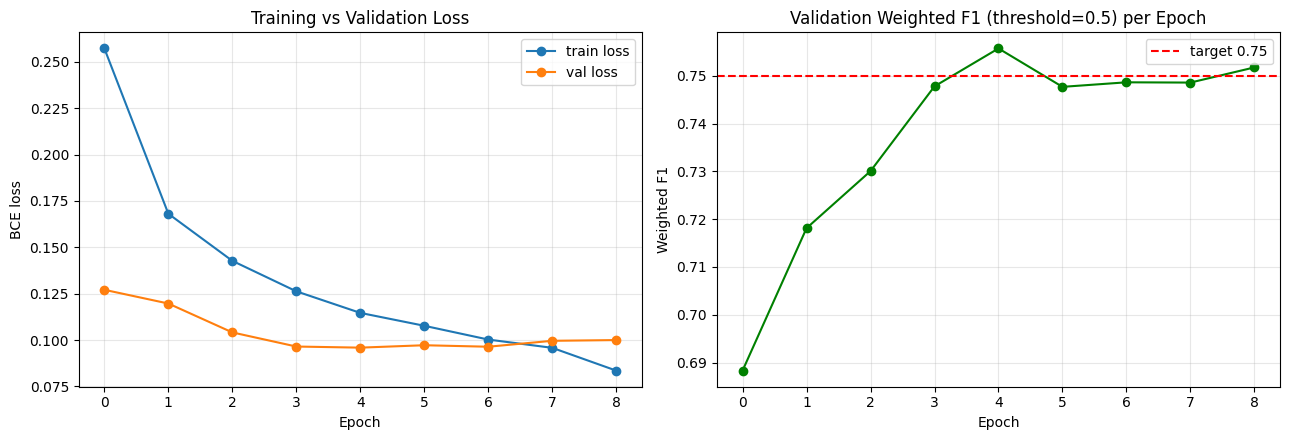

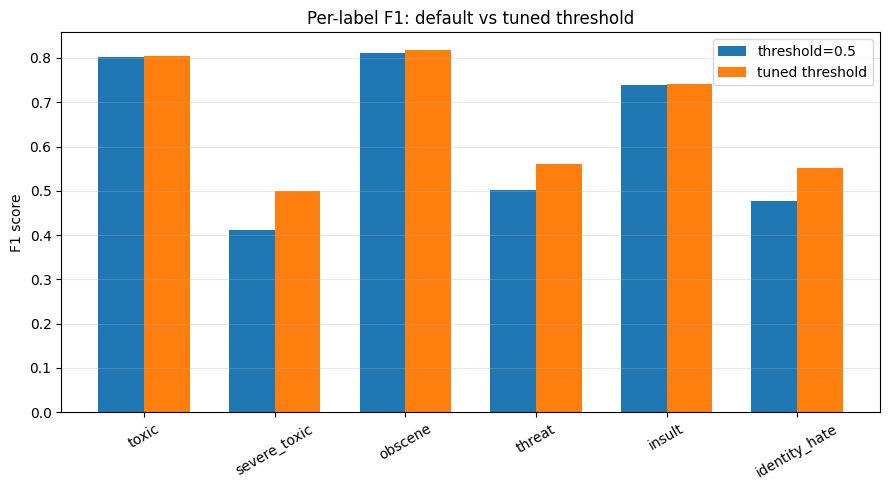

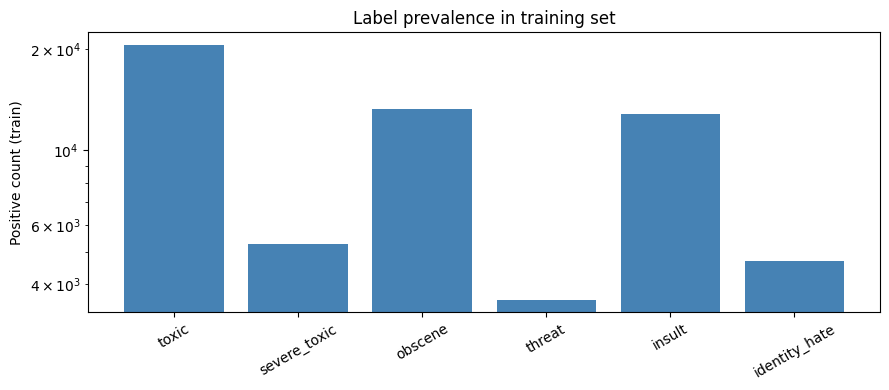

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(history['train_loss'], label='train loss', marker='o')
axes[0].plot(history['val_loss'], label='val loss', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCE loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history['val_weighted_f1'], color='green', marker='o')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Weighted F1')
axes[1].set_title('Validation Weighted F1 (threshold=0.5) per Epoch')
axes[1].axhline(0.75, color='red', linestyle='--', label='target 0.75')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Per-label F1: default threshold vs tuned threshold
default_per_label_f1 = f1_score(val_true, default_preds, average=None, zero_division=0)
tuned_per_label_f1 = f1_score(val_true, tuned_preds, average=None, zero_division=0)

x_pos = np.arange(len(LABEL_COLS))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x_pos - width/2, default_per_label_f1, width, label='threshold=0.5')
ax.bar(x_pos + width/2, tuned_per_label_f1, width, label='tuned threshold')
ax.set_xticks(x_pos)
ax.set_xticklabels(LABEL_COLS, rotation=30)
ax.set_ylabel('F1 score')
ax.set_title('Per-label F1: default vs tuned threshold')
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Label prevalence in train set, for reference alongside the F1 chart above
label_counts = train_labels.sum(axis=0)
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(LABEL_COLS, label_counts, color='steelblue')
ax.set_ylabel('Positive count (train)')
ax.set_title('Label prevalence in training set')
ax.set_yscale('log')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
